# OISST/MOM6 Sea Surface Temperature Comparison
Author: Brooke Hawkins

## Set up

In [1]:
import xarray as xr
import scipy
import numpy as np
import pandas as pd
import datetime
import time
import seaborn
import matplotlib.pyplot as plt

## Load data

In [2]:
# load datasets
sst_mom6 = xr.open_dataset("mom6/mom6_monthly_sst.nc")
sst_oisst = xr.open_dataset("oisst/TS_monthly.nc")

I confirmed that the MOM6 subset here has duplicates for the last six months of data, January to June of 2025. Each time step is duplicated once, and the values are identical. I need to fix this in the `sst-anomaly.ipynb` script before the data is written to netCDF.

In [3]:
# remove duplicates from MOM6
sst_mom6_dedupe = sst_mom6.drop_duplicates(dim="time", keep="first")

## Define spatial and temporal extents

In [4]:
# define spatial extent for California Current
x_lim = [-128, -116.8]
y_lim = [32, 48]

# define temporal extent for comparison based on MOM6 hindcast which has a shorter timeframe than OISST
time_bgn = sst_mom6_dedupe.time.to_index().min()
time_end = sst_mom6_dedupe.time.to_index().max()

print(f"Date range is {time_bgn} to {time_end}")

Date range is 1993-01-01 00:00:00 to 2025-06-01 00:00:00


In [5]:
# subset both datasets (add 360 to longitude for 0-360 coordinate scale)
sst_mom6_subset = sst_mom6_dedupe.sel(
    lat_vec=slice(y_lim[0], y_lim[1]),
    lon_vec=slice(x_lim[0] + 360, x_lim[1] + 360),
    time=slice(time_bgn, time_end),
)
sst_oisst_subset = sst_oisst.sel(
    lat_vec=slice(y_lim[0], y_lim[1]),
    lon_vec=slice(x_lim[0] + 360, x_lim[1] + 360),
    time=slice(time_bgn, time_end),
)

In [6]:
# check grid sizes
print("MOM6 dimensions: ", sst_mom6_subset.sizes)
print("OISST dimensions: ", sst_oisst_subset.sizes)


MOM6 dimensions:  Frozen({'time': 390, 'lat_vec': 187, 'lon_vec': 39})
OISST dimensions:  Frozen({'time': 390, 'lat_vec': 64, 'lon_vec': 45})


## Check grid resolutions and interpolate

In [7]:
def check_grid_resolution(dataset):
    """
    Analyzes the spatial resolution of a dataset's grid to determine if it is
    regular (uniform spacing), nearly regular (close to uniform spacing, some
    rounding error), or irregular.

    Args:
        dataset: An object (e.g., xarray Dataset) containing 'lat_vec' and 'lon_vec'
                 coordinate arrays that can be converted to pandas Series.
    """
    # check step size between adjacent latitude points to check for uniform spacing
    lat_series = dataset.lat_vec.to_series()
    lat_series_diff = lat_series.diff()
    lat_diff_min = lat_series_diff.min(skipna=True)
    lat_diff_max = lat_series_diff.max(skipna=True)

    # check step size between adjacent longitude points to check for uniform spacing
    lon_series = dataset.lon_vec.to_series()
    lon_series_diff = lon_series.diff()
    lon_diff_min = lon_series_diff.min(skipna=True)
    lon_diff_max = lon_series_diff.max(skipna=True)

    # classify grid resolution based on variance in step sizes
    if lat_diff_min == lat_diff_max and lon_diff_min == lon_diff_max:
        print(
            f"Perfectly regular grid resolution of {lat_diff_min} latitudinal degrees by {lon_diff_min} longitudinal degrees."
        )
    elif np.isclose(lat_diff_min, lat_diff_max) and np.isclose(
        lon_diff_min, lon_diff_max
    ):
        print(
            f"Nearly regular grid resolution of {lat_diff_min} latitudinal degrees by {lon_diff_min} longitudinal degrees."
        )
    else:
        print(
            f"Irregular grid resolution of {lat_diff_min} to {lat_diff_max} latitudinal degrees by {lon_diff_min} to {lon_diff_max} longitudinal degrees."
        )

In [8]:
check_grid_resolution(sst_oisst_subset)
check_grid_resolution(sst_mom6_subset)

Perfectly regular grid resolution of 0.25 latitudinal degrees by 0.25 longitudinal degrees.
Irregular grid resolution of 0.08588027954101562 to 0.08588409423828125 latitudinal degrees by 0.288360595703125 to 0.28839111328125 longitudinal degrees.


Since MOM6 has a higher resolution, I will interpolate the MOM6 data to the OISST grid. I will use bilinear interpolation using xarray's `interp_like` function, though I want to check with Darren if I should be using a more conservative approach (implement with `xESMF` library in python).

In [9]:
# interpolate MOM6 grid onto OISST grid
sst_mom6_interp = sst_mom6_subset.interp_like(sst_oisst_subset)

# check interpolated MOM6 grid size and resolution
print("MOM6 dimensions: ", sst_mom6_interp.sizes)
check_grid_resolution(sst_mom6_interp)

MOM6 dimensions:  Frozen({'time': 390, 'lat_vec': 64, 'lon_vec': 45})
Perfectly regular grid resolution of 0.25 latitudinal degrees by 0.25 longitudinal degrees.


Calculate weights based on latitude to area-weight statistics. The area of each 1/2 degree by 1/2 degree grid cell varies with latitude, since the distance that one degree of longitude represents shrinks when moving from the equator to the poles. If comparison statistics are not area weighted, then smaller cells further north (which are generally cooler waters) will bias comparisons.

In [10]:
# calculate latitude-based area weights
weights = np.cos(np.deg2rad(sst_oisst_subset.lat_vec))

## Comparisons

Calculate and visualize correlation, bias, and root mean squared error (RMSE).

### Correlation

In [11]:
# calculate correlation
# make sure to area weight calculation across spatial dimensions
correlation_global = xr.corr(
    sst_oisst_subset.sst, sst_mom6_interp.tos, weights=weights
).item()
correlation_temporal = xr.corr(
    sst_oisst_subset.sst,
    sst_mom6_interp.tos,
    dim=["lat_vec", "lon_vec"],
    weights=weights,
)
# no need to area weight calculation across time dimension
correlation_spatial = xr.corr(sst_oisst_subset.sst, sst_mom6_interp.tos, dim="time")

/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/arraylake_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [12]:
# print overall correlation
correlation_global

0.971954096625427

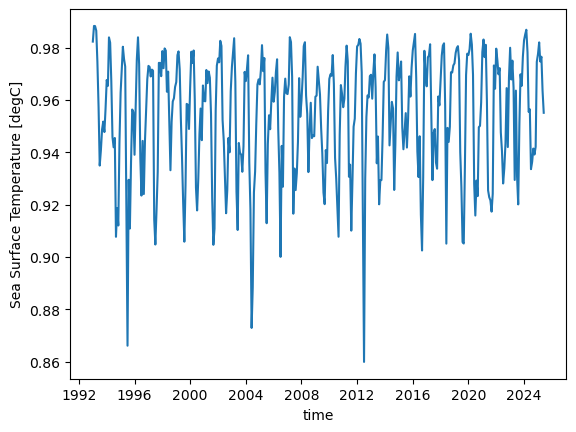

In [13]:
# visualize correlation over time
correlation_temporal.plot()

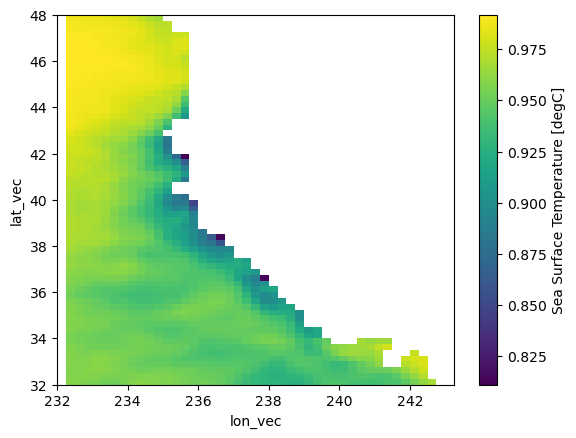

In [14]:
# visualize correlation over space (heatmap)
correlation_spatial.plot()

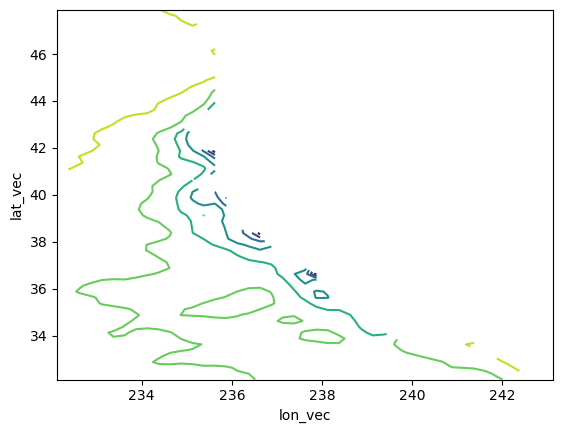

In [15]:
# visualize correlation over space (contour)
correlation_spatial.plot.contour()

### Bias

In [16]:
# calculate bias
error = sst_mom6_interp.tos - sst_oisst_subset.sst
error_weighted = error.weighted(weights)
# make sure to area weight calculation across spatial dimensions
bias_global = error_weighted.mean().item()
bias_temporal = error_weighted.mean(dim=["lat_vec", "lon_vec"])
# no need to area weight calculation across time dimension
bias_spatial = error.mean(dim="time")

In [17]:
# print overall bias
bias_global

0.1464345659465507

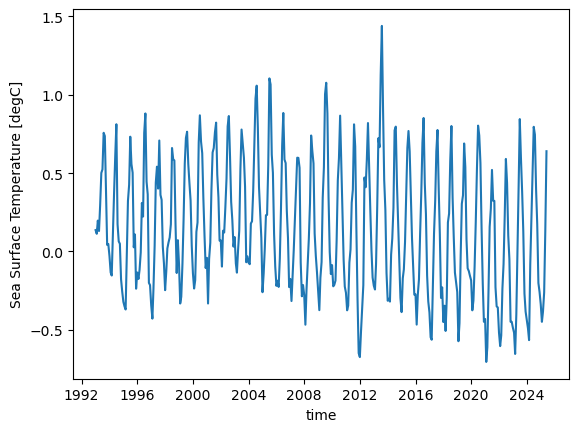

In [18]:
# visualize bias over time
bias_temporal.plot()

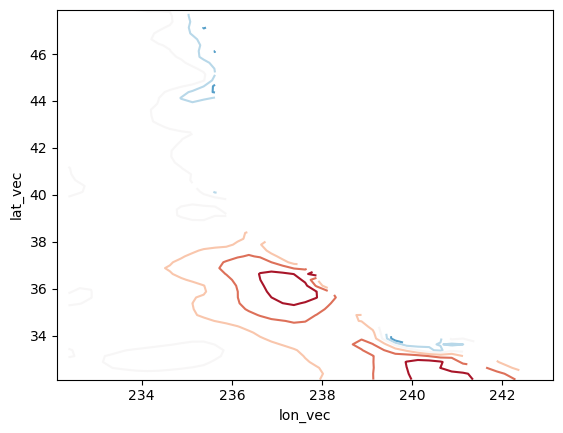

In [19]:
# visualize bias over space (contour)
bias_spatial.plot.contour()

### RMSE

In [20]:
# calculate RMSE
squared_error = error**2
squared_error_weighted = squared_error.weighted(weights)
# make sure to area weight calculation across spatial dimensions
rmse_global = np.sqrt((squared_error_weighted).mean()).item()
rmse_temporal = np.sqrt((squared_error_weighted).mean(dim=["lat_vec", "lon_vec"]))
# no need to area weight calculation across time dimension
rmse_spatial = np.sqrt((squared_error).mean(dim="time"))

In [21]:
# print overall RMSE
rmse_global

0.695559583542102

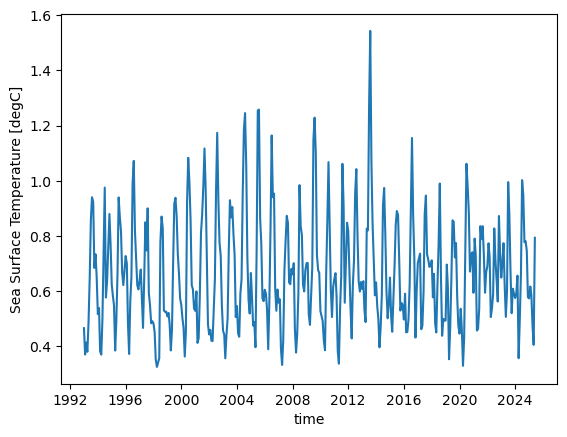

In [22]:
# visualize RMSE over time
rmse_temporal.plot()

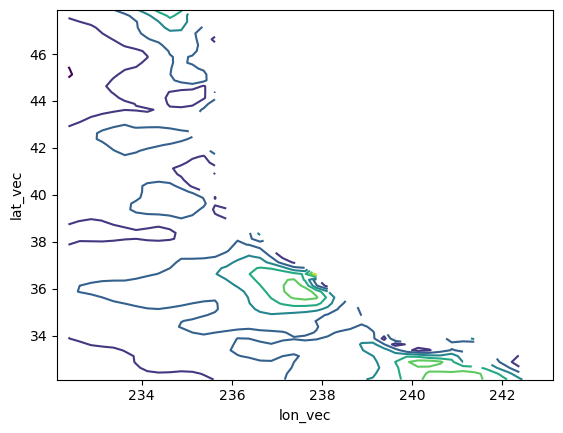

In [23]:
# visualize RMSE over space (contour)
rmse_spatial.plot.contour()